# 2024 Spoken Wiki attentional word recognition task results

### Analysis is for main diotic experiment
### Models run on all combinations of stimuli
___

In [169]:
import pickle

import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle
import importlib 
import IPython.display as ipd
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats 
# from matplotlib.ticker import FormatStrFormatter

import src.util_process_prolific as up 
from tqdm import tqdm
importlib.reload(up)

import matplotlib 
matplotlib.rcParams.update({'font.size': 10})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'

fig_out_dir = Path("final_figures/figure_2")
fig_out_dir.mkdir(exist_ok=True, parents=True)






### Import human data

In [170]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
path_to_expmt_stim = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_word_recognition_all_conds/data/*.json"))

len(human_fnames)

428

## Process Human Results

In [171]:
## Get all subject data into one df for analysis

dfs = []
for fname in human_fnames:
    try:
        dfs.append(up.get_part_df_swc(fname))
    except Exception as e:
        continue
        # print(e)
        # print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)
print(f"Total number of subjects: {len(results_df.id_subject.unique())}")

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]
print(f"Total number of subjects after headphone check: {len(results_df.id_subject.unique())}")
## Filter self reported hearing loss 
results_df = results_df[results_df.hearing_loss == False]
print(f"Total number of subjects after hearing loss check: {len(results_df.id_subject.unique())}")
# results_df = results_df[results_df.over_ear_hf == True]

## Add snr and condition names as columns - unpack from file code in file names 

# get cond name map
map_path = path_to_expmt_stim / 'human_attn_expmt_cond_map.pkl' 
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)
stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

# add as columns 
results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(lambda x: up.get_stim_snr_and_cond(x, stim_cond_map=stim_cond_map)))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str].copy()
trial_results.rename(columns={"condition":"raw_condition"}, inplace=True)

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                       "babble":"background_cv08talkerbabble",
                       "stationary": "background_issnstationary",
                       "natural scene": "background_ieeeaaspcasa",
                       "clean": "SILENCE"}
# 1-talker conds preserved in replace below

condition_map = {v:k for k,v in test_condition_dict.items()}
trial_results['condition'] = trial_results['raw_condition'].replace(condition_map)

# screen based on completion 
total_trials = 196
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]
# Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')

# add shortened stim name field 
trial_results['stim_name'] = trial_results['stimulus'].str.split('/').str[-1].str.split('.').str[0]

# drop coluns in trial_results that are all nans 
trial_results = trial_results.dropna(axis=1, how='all')
print(f"Total number of subjects after full run check: {len(trial_results.id_subject.unique())}")

Total number of subjects: 406
Total number of subjects after headphone check: 285
Total number of subjects after hearing loss check: 280
Total number of subjects after full run check: 208


In [172]:
# catch_trial_particiapnt_performance
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()

print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response.isna())]
analysis_df = analysis_df.dropna(axis=1, how='all').dropna(axis=0, how='all')
# analysis_df.groupby('id_subject').condition.count()

N total participants  208
N good participants  195


In [173]:
### Get quick demographics 
demog_fields = results_df[results_df.id_subject.isin(good_participants)]
demogs = demog_fields.groupby('id_subject').first()
print("Gender data")
print(demogs.gender.value_counts())
print("Age data")
demogs['age'] = [int(age) if age != '' else np.nan for age in demogs.age ]
print(f"Min: {demogs.age.min()} Max: {demogs.age.max()} Median: {demogs.age.median()}")

Gender data
gender
Female                  98
Male                    92
Other                    4
Prefer not to answer     1
Name: count, dtype: int64
Age data
Min: 18.0 Max: 71.0 Median: 33.0



#### Add re-scored performance based on entries included in excerpt transcripts  

In [174]:
### Make map from cv dictionary ixs to experiment word ixs 

## import cv maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


## import experiment word map
human_exp_word_key = pickle.load( open(path_to_expmt_stim / "human_attn_expmt_word_key.pkl", "rb" )) 
exp_word_2_class = {v:k for k,v in human_exp_word_key.items()}



In [175]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

manifests = pd.read_pickle(path_to_expmt_stim / "human_cue_target_distractor_df_w_meta_transcripts_w_f0.pdpkl")
# add columns for word int and stim name to map back to participant data 
manifests['word_fname_int'] = manifests['word'].replace(exp_word_2_class)
manifests['stim_name'] = manifests[['gender', 'word_fname_int']].apply(lambda row: f"{row.gender[0]}_{row.word_fname_int:03d}", axis=1)

cols_to_merge = ['stim_name',
                 'gender',
                 'word',
                 'target_f0',
                 'english_distractor_f0',
                 'mandarin_distractor_f0',
                 'dutch_distractor_f0',
                 'target_transcripts',
                 'same_sex_distractor_1_transcripts',
                 'diff_sex_distractor_1_transcripts',
                 "same_sex_dist_1_word",
                 "diff_sex_dist_1_word"
]

analysis_df = pd.merge(analysis_df,
                        manifests[cols_to_merge],
                                    left_on='stim_name', right_on='stim_name', how='left')
# analysis_df['confusions'] = (analysis_df.response == analysis_df.same_sex_dist_1_word).astype('int')
# analysis_df['accuracy'] = (analysis_df.response == analysis_df.word).astype('int')


# add adjusted accuracy and confusions 
pred_words = analysis_df.response.values
target_words = analysis_df.word.values
target_transcripts = analysis_df.target_transcripts.values
same_sex_distractor_words = analysis_df.same_sex_dist_1_word.values
diff_sex_distractor_words = analysis_df.diff_sex_dist_1_word.values
same_sex_distractor_transcripts = analysis_df.same_sex_distractor_1_transcripts.values
diff_sex_distractor_transcripts = analysis_df.diff_sex_distractor_1_transcripts.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not isinstance(target_transcript, float) else np.nan
                            for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                            ])

adjusted_confs = np.array([int(pred_word in same_sex_transcript or pred_word in diff_sex_transcript or pred_word == same_sex_word or pred_word == diff_sex_word)
                            if not (isinstance(same_sex_transcript, float) and isinstance(diff_sex_transcript, float)) else np.nan
                            for pred_word, same_sex_word, diff_sex_word, same_sex_transcript, diff_sex_transcript in zip(pred_words, same_sex_distractor_words, diff_sex_distractor_words,  same_sex_distractor_transcripts, diff_sex_distractor_transcripts)
                            ])

analysis_df['accuracy'] = adjusted_acc
analysis_df['confusions'] = adjusted_confs

## Remap 1-talker distractor names accordingly 

analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'sex_cond'] = analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'].str.split('-').str[-1].str.title()
analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'dist_lang'] = analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'].str.split('-').str[-2].str.title()

def remap_1_distractor_str(cond_str):
    if 'english' in cond_str:
        return '1-talker'
    if 'mandarin' in cond_str:
        return "Mandarin distractor"
    if 'dutch' in cond_str:
        return "Dutch distractor"

analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'] = analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'].apply(remap_1_distractor_str)
analysis_df = analysis_df[~analysis_df.condition.isin(['catch_trial', "Dutch distractor"])]
analysis_df['stim_name'] = analysis_df['condition'] + "_" + analysis_df['stim_name'] + "_" + analysis_df['snr'].astype(str) + "dB"


/tmp/ipykernel_3950190/945560939.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  manifests['word_fname_int'] = manifests['word'].replace(exp_word_2_class)


In [176]:
##########################
# Make df for f0 analysis 
##########################

# drop unwanted conditions
f0_analysis_df = analysis_df[analysis_df.condition.isin([ "1-talker", 'Mandarin distractor', 'clean'])].copy()

# cut and remove language-specific f0 columns - just make distractor f0 
f0_analysis_df.loc[f0_analysis_df.dist_lang == 'English', 'distractor_f0'] = f0_analysis_df.loc[f0_analysis_df.dist_lang == 'English', 'english_distractor_f0'].values
f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Mandarin', 'distractor_f0'] = f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Mandarin', 'mandarin_distractor_f0'].values
# f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Dutch', 'distractor_f0'] = f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Dutch', 'dutch_distractor_f0'].values

f0_analysis_df["abs_f0_diff"] = np.abs(f0_analysis_df.target_f0 - f0_analysis_df.distractor_f0)
f0_analysis_df["percent_f0_diff"] = f0_analysis_df.distractor_f0 / f0_analysis_df.target_f0 
def get_f0_ratio(row):
    return max(row.target_f0, row.distractor_f0) / min(row.target_f0, row.distractor_f0)
f0_analysis_df["f0_ratio"] = f0_analysis_df.apply(get_f0_ratio, axis=1)

# # rename condition to background condition
f0_analysis_df = f0_analysis_df.rename(columns={"condition": "background_condition"})
f0_analysis_df = f0_analysis_df.dropna(axis=1,  how = 'all')
# get columns with trial in their name
cols_to_drop = [col for col in f0_analysis_df.columns if 'trial' in col ]
# drop prolific meta columns
f0_analysis_df = f0_analysis_df.drop(columns=cols_to_drop).reset_index(drop=True)


In [177]:
# get trial data excluding catch trials 

part_summary_df = (analysis_df.groupby(["stim_name", "snr", 'id_subject', "condition"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean']})
                     .reset_index())

part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


/tmp/ipykernel_3950190/2161386446.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)


In [178]:
part_summary_df

,stim_name,snr,id_subject,condition,correct_mean,correct_count,confusions_mean
0,1-talker_f_000_-3dB,-3,665a6f7b05463883cf73fe17,1-talker,0.0,1,0.0
1,1-talker_f_000_-6dB,-6,5654175604212700054a12b1,1-talker,0.0,1,1.0
2,1-talker_f_000_-6dB,-6,6685332a4bd40063f0f6a8b6,1-talker,0.0,1,0.0
3,1-talker_f_000_-9dB,-9,63d3fd1b0a21df494a093c51,1-talker,0.0,1,1.0
4,1-talker_f_000_3dB,3,63dd3dd2593c92be97d8dbde,1-talker,0.0,1,0.0
...,...,...,...,...,...,...,...
31942,stationary_m_485_-3dB,-3,668bb6a70c92907a25c9895f,stationary,1.0,1,0.0
31943,stationary_m_485_-9dB,-9,5877066b1ed9d10001050b9a,stationary,0.0,1,0.0
31944,stationary_m_487_-6dB,-6,6684a041fab730aec2c2c637,stationary,0.0,1,0.0
31945,stationary_m_487_-9dB,-9,57f3f1d73c11ac0001ce6da3,stationary,0.0,1,0.0


In [179]:
## Summarize participant data for aggregate plotting


summary_df = part_summary_df.groupby(['stim_name', 'snr', 'condition']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count']}).reset_index()
summary_df.columns = ['stim_name', 'snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N']


## Load Model Results 

In [180]:
## import class maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}

### Get conditions 
cond_map = pickle.load( open(path_to_expmt_stim / "human_attn_expmt_cond_map.pkl", "rb" )) 
conds = set([cond for cond,snr in cond_map.values()])

test_cond_to_human = {v:k for k,v in test_condition_dict.items()}
cond_remap = {}
for cond in conds:
    if cond in test_cond_to_human:
        cond_remap[cond] = test_cond_to_human[cond]
    else:
        cond_remap[cond] = cond 
cond_remap['natural scene'] = 'natural scene'


In [181]:

model_names = [
    # "word_task_half_co_loc_v10_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout",
                # "word_task_v08_control_no_attn",
                # "word_task_v10_control_no_attn",
                # "word_task_early_only_v10",
                # "word_task_late_only_v10",
                # "word_task_half_co_loc_v10_50Hz_cutoff",
                # "word_task_conventional_layer_order"
                ]# "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned"]

# get names for arch_search models 
arch_search_models = [path.stem for path in Path('swc_2024_eval_full_stim/').glob('*v10*')]
model_names.extend(arch_search_models)

model_name_dict = {
                   'word_task_v10_control_no_attn': 'Baseline CNN',
                   'word_task_early_only_v10': 'Early-only',
                   'word_task_late_only_v10': 'Late-only',
                   "word_task_v10_main_feature_gain_config": 'Feature-gain Model',

                  }




all_model_results = []
all_model_f0_results = []

background_conditions = summary_df.background_condition.unique() 
str_to_cond = {v:k for k,v in test_condition_dict.items()}

## preselect manifest columns 
cols_to_merge = [
                #  'stim_name',
                 'gender',
                 'word',
                 'word_int',
                 'target_f0',
                 'english_distractor_f0',
                 'mandarin_distractor_f0',
                 'dutch_distractor_f0',
                 'target_transcripts',
                 'same_sex_distractor_1_transcripts',
                 'diff_sex_distractor_1_transcripts',
                 "same_sex_dist_1_word",
                 "diff_sex_dist_1_word",
                 'stim_name'

]

manifests['word_int'] = manifests.word.replace(cv_word_2_class)
model_manifest = manifests[cols_to_merge].sort_values(['gender', 'word']).copy()
model_manifest['df_index'] = model_manifest.index

# update gt manifests to match readable format 
for model_name in model_names:
    print(model_name)
    output_paths = list(Path(f'swc_2024_eval_full_stim/{model_name}').glob('*.csv'))
    print(len(output_paths))
    results_dfs = []

    for path in output_paths:
        # print(path)
        try:
            df = pd.read_csv(path)
            # reformat dict
            df['model'] = path.parent.name
            #parts of name 
            parts = path.stem.split(path.parent.name)[-1].split('_')   
            # if 'stim_tag' in df.columns:
            #     # rename 
            #     df.rename(columns={'stim_tag':'stim_name'}, inplace=True)
            # use re to split path.stem after model name and before <int>dB 
            df['background_condition'] = [v for v in cond_remap.values() if "_".join(v.split(' ')) in path.stem][0]
            if 'clean' in path.stem:
                df['background_condition'] = 'clean'
                df['snr'] =  'inf' # really np.inf, 6 for plotting 
            else:
                df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))

            df['test_index'] = df.index
            df = pd.merge(df,
                model_manifest,
                            left_on=["test_index", "true_word_int"], right_on=["df_index", "word_int"])
            if 'dutch' in df['background_condition'].unique()[0]:
                continue
            results_dfs.append(df)
        except Exception as e:
            # print(e)
            continue

    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    if model_name in model_name_dict:
        model_str = model_name_dict[model_name]
    elif "arch_" in model_name:
        model_str = "Feature-gain Model"
    else:
        model_str = model_name

    model_results['group'] = model_str
    ## Load in model vocab 
    model_results['pred_word'] = model_results['pred_word_int'].replace(cv_class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(cv_class_2_word)


    # Add 1-talker condition metadata to model results

    # add confusions 
    model_results['confusions'] = (model_results.pred_word == model_results.same_sex_dist_1_word).astype('int')

    # add adjusted accuracy and confusions 
    pred_words = model_results.pred_word.values
    target_words = model_results.word.values
    target_transcripts = model_results.target_transcripts.values
    same_sex_distractor_words = model_results.same_sex_dist_1_word.values
    diff_sex_distractor_words = model_results.same_sex_dist_1_word.values
    same_sex_distractor_transcripts = model_results.same_sex_distractor_1_transcripts.values
    diff_sex_distractor_transcripts = model_results.diff_sex_distractor_1_transcripts.values


    adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                                if not isinstance(target_transcript, float) else np.nan
                                for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                                ])

    adjusted_confs = np.array([int(pred_word in same_sex_transcript or pred_word in diff_sex_transcript or pred_word == same_sex_word or pred_word == diff_sex_word)
                                if not (isinstance(same_sex_transcript, float) and isinstance(diff_sex_transcript, float)) else np.nan
                                for pred_word, same_sex_word, diff_sex_word, same_sex_transcript, diff_sex_transcript in zip(pred_words, same_sex_distractor_words, diff_sex_distractor_words,  same_sex_distractor_transcripts, diff_sex_distractor_transcripts)
                                ])
    
    model_results['accuracy'] = adjusted_acc
    model_results['confusions'] = adjusted_confs
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'sex_cond'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].str.split('-').str[-1].str.title()
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'dist_lang'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].str.split('-').str[-2].str.title()
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].apply(remap_1_distractor_str)

    
    all_model_results.append(model_results)


    model_f0_df = model_results[model_results.background_condition.isin([ "1-talker", 'Mandarin distractor', 'Dutch distractor', 'clean'])].copy()
    model_f0_df.loc[model_f0_df.dist_lang == 'English', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'English', 'english_distractor_f0'].values
    model_f0_df.loc[model_f0_df.dist_lang == 'Mandarin', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'Mandarin', 'mandarin_distractor_f0'].values
    model_f0_df.loc[model_f0_df.dist_lang == 'Dutch', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'Dutch', 'dutch_distractor_f0'].values
    model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df["percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    model_f0_df["f0_ratio"] = model_f0_df.apply(get_f0_ratio, axis=1)
    model_f0_df.loc[:, "abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df.loc[:, "percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    all_model_f0_results.append(model_f0_df)

all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
all_model_f0_results = pd.concat(all_model_f0_results, axis=0, ignore_index=True)
all_model_results['stim_name'] = all_model_results['background_condition'] + "_" + all_model_results['stim_name'] + '_' + all_model_results['snr'].astype(str) + 'dB'

/tmp/ipykernel_3950190/2630698386.py:51: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  manifests['word_int'] = manifests.word.replace(cv_word_2_class)


word_task_early_only_v10
61
word_task_late_only_v10
61
word_task_v10_4MGB_ln_first_arch_1
61
word_task_v10_4MGB_ln_first_arch_10
61
word_task_v10_4MGB_ln_first_arch_12
61
word_task_v10_4MGB_ln_first_arch_2
61
word_task_v10_4MGB_ln_first_arch_4
61
word_task_v10_4MGB_ln_first_arch_6
61
word_task_v10_4MGB_ln_first_arch_7
61
word_task_v10_4MGB_ln_first_arch_8
61
word_task_v10_4MGB_ln_first_arch_9
61
word_task_v10_backbone_learned_gains
61
word_task_v10_backbone_word_babble_and_noise_no_gains
61
word_task_v10_backbone_word_babble_and_noise_no_gains_old_no-use
61
word_task_v10_backbone_word_config_ecdf_gains
61
word_task_v10_backbone_word_config_no_gains
61
word_task_v10_backbone_word_config_no_gains_old_ckpt
61
word_task_v10_backbone_word_config_old_ckpt
61
word_task_v10_backbone_word_config_saddler_dataset_learned_gains
61
word_task_v10_backbone_word_config_saddler_dataset_no_gains
61
word_task_v10_backbone_word_config_saddler_dataset_no_gains_old_ckpt
61
word_task_v10_backbone_word_config

# Main analysis of Model averages vs Humans 

In [182]:
### Merge all feature based models into one group

models_to_summary = all_model_results[all_model_results.group == "Feature-gain Model"].copy()

## Summarize participant data for aggregate plotting
# get trial data excluding catch trials 


models_summary_df = (models_to_summary.groupby(['model', "stim_name", "snr", "background_condition"])
                     .agg({'accuracy':['mean', 'count'],
                            'confusions':['mean']})
                     .reset_index())

models_summary_df['snr'] = models_summary_df['snr'].replace(np.inf, 6)
models_summary_df['snr'] =  models_summary_df['snr'].replace("inf", 6)
models_summary_df['snr'] = models_summary_df['snr'].astype('int')
# flatten multiindex 
models_summary_df.columns = ['_'.join(col).strip() for col in models_summary_df.columns.values]
# remove trailing underscore
models_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in models_summary_df.columns.values]


fba_summary_df = models_summary_df.groupby(['stim_name', 'snr', 'background_condition']).agg({'accuracy_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count']}).reset_index()
fba_summary_df.columns = ['stim_name', 'snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N']
fba_summary_df['group'] = 'Feature-gain Model'

control_model_summary = all_model_results[all_model_results.group.str.contains('Baseline|Early|Late')].copy()

control_model_summary = (control_model_summary.groupby(['group', "stim_name", "snr", "background_condition"])
                     .agg({'accuracy':['mean', 'sem'],
                            'confusions':['mean', 'sem', 'count']})
                     .reset_index())

control_model_summary['snr'] =  control_model_summary['snr'].replace("inf", 6)
control_model_summary['snr'] = control_model_summary['snr'].astype('int')
control_model_summary.columns = ['group', 'stim_name', 'snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N']


/tmp/ipykernel_3950190/4062238513.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  models_summary_df['snr'] =  models_summary_df['snr'].replace("inf", 6)
/tmp/ipykernel_3950190/4062238513.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  control_model_summary['snr'] =  control_model_summary['snr'].replace("inf", 6)


In [183]:
fba_summary_df

,stim_name,snr,background_condition,accuracy,acc_std_error,confusions,conf_std_error,N,group
0,1-talker_f_000_-3dB,-3,1-talker,0.50,0.074536,0.0,0.0,10,Feature-gain Model
1,1-talker_f_000_-6dB,-6,1-talker,0.45,0.050000,0.0,0.0,10,Feature-gain Model
2,1-talker_f_000_-9dB,-9,1-talker,0.30,0.081650,0.0,0.0,10,Feature-gain Model
3,1-talker_f_000_0dB,0,1-talker,0.60,0.100000,0.0,0.0,10,Feature-gain Model
4,1-talker_f_000_3dB,3,1-talker,0.85,0.076376,0.0,0.0,10,Feature-gain Model
...,...,...,...,...,...,...,...,...,...
40011,stationary_m_487_-3dB,-3,stationary,0.20,0.133333,0.0,0.0,10,Feature-gain Model
40012,stationary_m_487_-6dB,-6,stationary,0.00,0.000000,0.0,0.0,10,Feature-gain Model
40013,stationary_m_487_-9dB,-9,stationary,0.00,0.000000,0.0,0.0,10,Feature-gain Model
40014,stationary_m_487_0dB,0,stationary,0.60,0.163299,0.0,0.0,10,Feature-gain Model


In [184]:
all_model_df = pd.concat([fba_summary_df, control_model_summary], axis=0, ignore_index=True)

In [185]:
human_filtered

,stim_name,snr,background_condition,accuracy,acc_std_error,confusions,conf_std_error,N
0,1-talker_f_000_-3dB,-3,1-talker,0.0,NaN,0.0,NaN,1
1,1-talker_f_000_-6dB,-6,1-talker,0.0,0.0,0.5,0.5,2
2,1-talker_f_000_-9dB,-9,1-talker,0.0,NaN,1.0,NaN,1
3,1-talker_f_000_3dB,3,1-talker,0.0,0.0,0.0,0.0,2
4,1-talker_f_001_-3dB,-3,1-talker,1.0,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...
2689,1-talker_m_486_-6dB,-6,1-talker,0.0,NaN,0.0,NaN,1
2690,1-talker_m_486_0dB,0,1-talker,0.5,0.5,0.0,0.0,2
2691,1-talker_m_487_-6dB,-6,1-talker,1.0,0.0,0.0,0.0,2
2692,1-talker_m_487_-9dB,-9,1-talker,1.0,NaN,0.0,NaN,1


In [194]:
human_for_analysis = pd.melt(summary_df, id_vars=['stim_name', 'snr', 'background_condition', 'N'], value_vars=['accuracy', 'confusions'], var_name='metric', value_name='measure')    

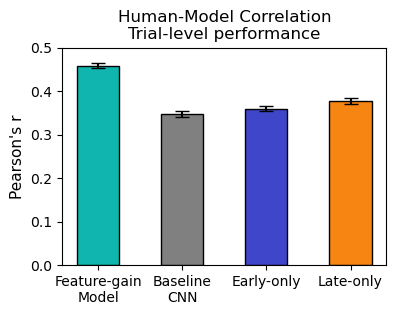

In [196]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from src import util_analysis 
from copy import deepcopy

model_color_dict = deepcopy(util_analysis.model_color_dict)

# === Setup ===
measure = 'measure'
n_boot = 1000  # Number of bootstrap samples

# Normalize condition names
all_model_df['background_condition'] = all_model_df['background_condition'].replace({'stationary': 'noise'})
summary_df['background_condition'] = summary_df['background_condition'].replace({'stationary': 'noise'})

# === Melt dataframes to pool accuracy and confusions ===
all_model_for_analysis = pd.melt(all_model_df, id_vars=['stim_name', 'group', 'background_condition'], value_vars=['accuracy', 'confusions'], var_name='metric', value_name='measure')
human_for_analysis = pd.melt(summary_df, id_vars=['stim_name', 'snr', 'background_condition', 'N'], value_vars=['accuracy', 'confusions'], var_name='metric', value_name='measure')    

# remove confusions if background condition not 1-talker
all_model_for_analysis = all_model_for_analysis[~((all_model_for_analysis.metric == 'confusions') & (~all_model_for_analysis.background_condition.str.contains('1-talker')))]
human_for_analysis = human_for_analysis[~((human_for_analysis.metric == 'confusions') & (~human_for_analysis.background_condition.str.contains('1-talker')))]


# Filter human data
human_filtered = human_for_analysis[human_for_analysis.N >= 1].copy()
model_names = all_model_for_analysis.group.unique()

# === Compute correlations and bootstrapped error bars ===
avg_corrs = []
boot_se = []

for model_name in model_names:
    model_df = all_model_for_analysis[all_model_for_analysis.group == model_name]

    # Mean accuracy per stimulus (pooled across all conditions/SNRs)
    human_means = human_filtered.groupby('stim_name')[measure].mean()
    model_means = model_df.groupby('stim_name')[measure].mean()

    # Match on common stimuli
    common = human_means.index.intersection(model_means.index)
    human_vals = human_means[common].values
    model_vals = model_means[common].values

    if len(common) >= 2:
        # Original correlation
        r, _ = pearsonr(human_vals, model_vals)
        avg_corrs.append(r)

        # Bootstrap
        boot_corrs = []
        n = len(common)
        rng = np.random.default_rng(seed=42)  # For reproducibility
        for _ in range(n_boot):
            idx = rng.integers(0, n, n)  # Sample with replacement
            r_b, _ = pearsonr(human_vals[idx], model_vals[idx])
            boot_corrs.append(r_b)

        # Compute standard error
        boot_corrs = np.array(boot_corrs)
        boot_se.append(np.nanstd(boot_corrs))
    else:
        avg_corrs.append(np.nan)
        boot_se.append(np.nan)

# === Plot ===

model_order = deepcopy(util_analysis.model_name_order)
aspect = 3.25
fontsize = 10
bar_width = 0.5

xtick_labels = model_order.copy()
xtick_labels[0] = "Feature-gain\nModel"
xtick_labels[1] = "Baseline\nCNN"

fig, ax = plt.subplots(figsize=(aspect * 1.25, aspect))

x = np.arange(len(model_names))
colors = [model_color_dict.get(name, 'gray') for name in model_names]

# Bar plot with error bars
ax.bar(x, avg_corrs, yerr=boot_se, capsize=5, width=bar_width,
       color=colors, edgecolor='black')

ax.set_ylim(0, 0.5)
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, fontsize=10)
ax.set_ylabel("Pearson's r", fontsize=11)
ax.set_title(f"Human-Model Correlation\nTrial-level performance", fontsize=12)

plt.tight_layout()
plt.show()


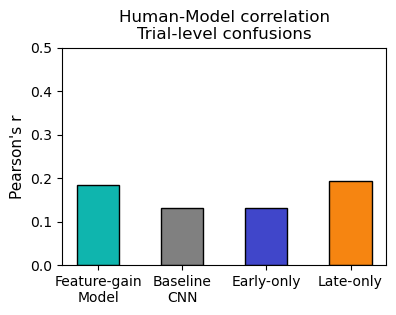

In [164]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from src import util_analysis 
from copy import deepcopy


model_color_dict = deepcopy(util_analysis.model_color_dict)


# === Setup ===
measure = 'confusions'  # or 'confusions'

# Normalize condition names
all_model_df['background_condition'] = all_model_df['background_condition'].replace({'stationary': 'noise'})
summary_df['background_condition'] = summary_df['background_condition'].replace({'stationary': 'noise'})

# only use 1-talker condition for confusions
all_model_df = all_model_df[all_model_df.background_condition == '1-talker']
summary_df = summary_df[summary_df.background_condition == '1-talker']


# Filter human data
human_filtered = summary_df[summary_df.N >= 1].copy()
model_names = all_model_df.group.unique()

# === Compute correlations across all data for each model ===
avg_corrs = []

for model_name in model_names:
    model_df = all_model_df[all_model_df.group == model_name]

    # Group across ALL SNRs and conditions: average per stimulus
    human_means = human_filtered.groupby('stim_name')[measure].mean()
    model_means = model_df.groupby('stim_name')[measure].mean()

    # Match stimuli
    common = human_means.index.intersection(model_means.index)
    if len(common) >= 2:
        r, _ = pearsonr(human_means[common], model_means[common])
        avg_corr = r
    else:
        avg_corr = np.nan

    avg_corrs.append(avg_corr)

# === Plot ===

model_order = deepcopy(util_analysis.model_name_order)


aspect = 3.25
fontsize = 10
bar_width = 0.5
xtick_labels = model_order.copy()
xtick_labels[0] = "Feature-gain\nModel"
xtick_labels[1] = "Baseline\nCNN"

fig, ax = plt.subplots(figsize=(aspect*1.25, aspect))

x = np.arange(len(model_names))
colors = [model_color_dict.get(name, 'gray') for name in model_names]
plt.bar(x, avg_corrs, color=colors, edgecolor='black' , width=bar_width, )
plt.ylim(0,0.5)
plt.xticks(x, xtick_labels, fontsize=10)
plt.ylabel(f"Pearson's r", fontsize=11)
# plt.ylim(-0.1, 1)
# plt.axhline(0, color='gray', linestyle='--')
plt.title(f"Human-Model correlation\nTrial-level {measure}", fontsize=12)
plt.tight_layout()
plt.show()


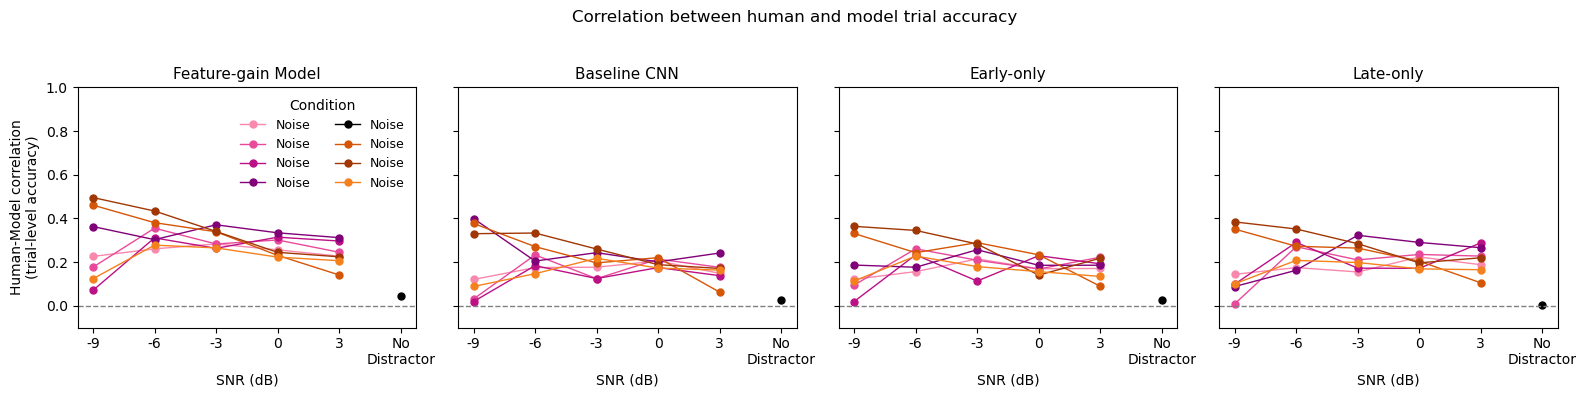

In [135]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# === Setup ===
snrs = sorted(summary_df.snr.unique())
measure = 'accuracy'  # or 'confusions'

model_names = all_model_df.group.unique()  
# replace stationary with onise on background_condition column 
all_model_df['background_condition'] = all_model_df['background_condition'].replace({'stationary':'noise'})

# Filter human data
human_filtered = summary_df[summary_df.N >= 1].copy()
human_filtered['background_condition'] = human_filtered['background_condition'].replace({'stationary':'noise'})
conditions = [cond for cond in sorted(human_filtered.background_condition.dropna().unique()) if "Mandar" not in cond]

# === Compute correlations for each model ===
# corr_by_model[model][condition] = list of r-values (one per snr)
corr_by_model = {model: {cond: [] for cond in conditions} for model in model_names}

for model_name in model_names:
    model_df = all_model_df[all_model_df.group == model_name]
    
    for cond in conditions:
        for snr in snrs:
            # Filter and summarize
            human_subset = human_filtered[
                (human_filtered.background_condition == cond) & 
                (human_filtered.snr == snr)
            ]
            model_subset = model_df[
                (model_df.background_condition == cond) & 
                (model_df.snr == snr)
            ]

            # Mean per stim
            human_means = human_subset.groupby('stim_name')[measure].mean()
            model_means = model_subset.groupby('stim_name')[measure].mean()

            # Join on common stim_names
            common = human_means.index.intersection(model_means.index)
            if len(common) < 2:
                corr = np.nan
            else:
                r, _ = pearsonr(human_means[common], model_means[common])
                corr = r

            corr_by_model[model_name][cond].append(corr)

# === Plot: one column per model ===
n_models = len(model_names)
fig, axs = plt.subplots(1, n_models, figsize=(4 * n_models, 4), sharey=True)

if n_models == 1:
    axs = [axs]  # Ensure axs is iterable

for i, model_name in enumerate(model_names):
    ax = axs[i]
    for cond, r_values in corr_by_model[model_name].items():
        ax.plot(snrs, r_values, marker='o', ms=5, linewidth=1, color=palette[cond], label=plot_label.title())

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel("SNR (dB)", fontsize=10)
    ax.set_xticks(snrs)
    ax.set_xticklabels([str(snr) if snr != 6 else "No\nDistractor" for snr in snrs], fontsize=10)
    ax.set_title(f"{model_name}", fontsize=11)
    if i == 0:
        ax.set_ylabel(f"Human-Model correlation\n(trial-level {measure})", fontsize=10)
    if i == 0:
        ax.legend(title="Condition", frameon=False, ncol=2, fontsize=9)
    ax.set_ylim(-0.1, 1)

plt.suptitle(f"Correlation between human and model trial {measure}", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


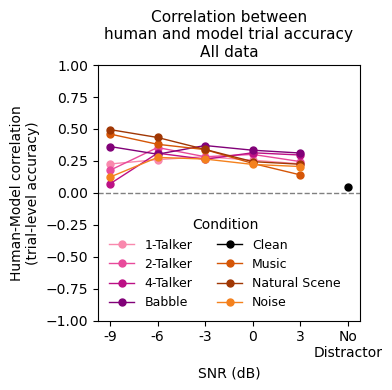

In [109]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# === Setup ===
snrs = sorted(summary_df.snr.unique())
conditions = [cond for cond in sorted(summary_df.background_condition.dropna().unique()) if "Mandar" not in cond]  # or manually define
measure = 'accuracy'  # or 'confusions'

# Filter human data with enough trials
human_filtered = summary_df[summary_df.N >= 1].copy()

# Store results: {condition: [r-values for each SNR]}
corr_by_condition = {cond: [] for cond in conditions}

# === Compute correlation for each (condition, SNR) ===
for cond in conditions:
    for snr in snrs:
        # Filter and summarize
        human_subset = human_filtered[(human_filtered.background_condition == cond) & (human_filtered.snr == snr)]
        model_subset = fba_summary_df[(fba_summary_df.background_condition == cond) & (fba_summary_df.snr == snr)]

        # Mean per stim
        human_means = human_subset.groupby('stim_name')[measure].mean()
        model_means = model_subset.groupby('stim_name')[measure].mean()

        # Join on common stim_names
        common = human_means.index.intersection(model_means.index)
        # print(f"SNR: {snr}, Condition: {cond}, Common Stimuli: {len(common)}")
        if len(common) < 2:
            corr = np.nan  # not enough data
        else:
            r, _ = pearsonr(human_means[common], model_means[common])
            corr = r

        corr_by_condition[cond].append(corr)

# === Plot ===
plt.figure(figsize=(4, 4))

for cond, r_values in corr_by_condition.items():
    cond = 'noise' if cond == 'stationary' else cond  # rename for clarity
    plt.plot(snrs, r_values, marker='o', ms=5, linewidth=1, color=palette[cond], label=cond.title())

fontsize = 10
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel("SNR (dB)", fontsize=fontsize)
plt.xticks(snrs, labels=[str(snr) if snr != 6 else "No\nDistractor" for snr in snrs], fontsize=fontsize)
plt.ylabel(f"Human-Model correlation\n(trial-level {measure})", fontsize=fontsize)
plt.title(f"Correlation between\nhuman and model trial {measure}\nAll data", fontsize=fontsize + 1)
plt.legend(title="Condition", frameon=False, ncol=2, fontsize=fontsize-1)
plt.ylim(-1, 1)
# plt.grid(True)
plt.tight_layout()


## Look at performance in 1-distractor condition

In [ ]:
from importlib import reload
from src import util_analysis 
reload(util_analysis)
diotic_exp_color_palette = util_analysis.diotic_exp_color_palette

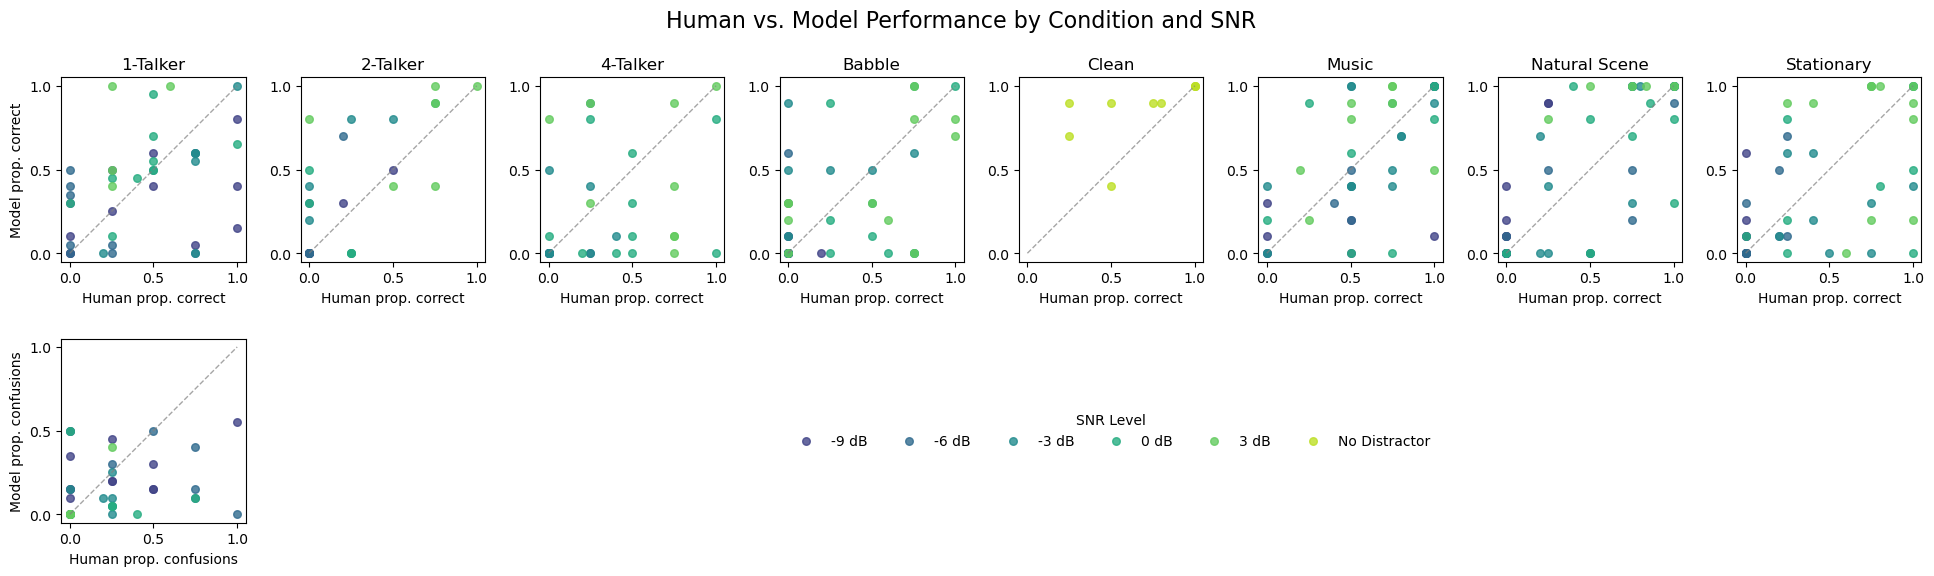

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# === Setup ===
snrs = sorted(summary_df.snr.unique())
conditions = [cond for cond in sorted(summary_df.background_condition.dropna().unique()) if "Mandar" not in cond]  # or manually define

n_cols = len(conditions)
n_rows = 2  # accuracy and confusions
aspect = 3

palette = diotic_exp_color_palette()  # Optional: your own palette

# Use matplotlib colormap to differentiate SNRs
snr_colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(snrs)))

human_to_compare = summary_df[summary_df.N >= 4].copy()

# === Utility Functions ===
def summarize_data(df):
    return df.groupby('stim_name').agg(
        accuracy_mean=('accuracy', 'mean'),
        accuracy_sem=('accuracy', 'sem'),
        confusion_mean=('confusions', 'mean'),
        confusion_sem=('confusions', 'sem')
    ).reset_index()

def select_df(df, snr, cond):
    return df[(df.snr == snr) & (df.background_condition == cond)]

# === Create Figure ===
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(n_cols * aspect, n_rows * aspect),
    sharex=False,
    sharey=False
)
fig.suptitle("Human vs. Model Performance by Condition and SNR", fontsize=16)

# === Loop over Conditions (columns) ===
for col_i, cond in enumerate(conditions):
    ax_acc = axes[0, col_i]
    ax_conf = axes[1, col_i]

    # Diagonal reference lines
    ax_acc.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, alpha=0.7)
    if col_i == 0:
        ax_conf.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, alpha=0.7)

    # Loop over SNRs, overlay data
    for snr_i, snr in enumerate(snrs):
        color = snr_colors[snr_i]
        label = f"{snr} dB" if snr != 6 else "No Distractor"

        model_data = summarize_data(select_df(fba_summary_df, snr, cond))
        human_data = summarize_data(select_df(human_to_compare, snr, cond))

        # Match on common stim_names
        common_stims = set(model_data.stim_name) & set(human_data.stim_name)
        model_data = model_data[model_data.stim_name.isin(common_stims)].sort_values('stim_name')
        human_data = human_data[human_data.stim_name.isin(common_stims)].sort_values('stim_name')

        # Scatter plots
        ax_acc.scatter(
            human_data.accuracy_mean,
            model_data.accuracy_mean,
            s=30,
            color=color,
            alpha=0.8,
            label=label if col_i == n_cols - 1 else None  # Show legend only on last column
        )
        if col_i == 0:
            ax_conf.scatter(
                human_data.confusion_mean,
                model_data.confusion_mean,
                s=30,
                color=color,
                alpha=0.8
            )
        else:
            ax_conf.axis('off')

    # Set titles
    ax_acc.set_title(cond.title())

# === Formatting Axes ===
for row in range(n_rows):
    for col in range(n_cols):
        ax = axes[row, col]
        measure = 'correct' if row == 0 else 'confusions'
        if col == 0:
            ax.set_ylabel(f"Model prop. {measure}")
        ax.set_xlabel(f"Human prop. {measure}")

        ticks = np.linspace(0, 1, 3)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xlim([-0.05, 1.05])
        ax.set_ylim([-0.05, 1.05])
        ax.set_aspect('equal', adjustable='box')

# === Legend (only once) ===
# === Place Legend inside an empty confusion panel (e.g., last column) ===
legend_ax = axes[1, 4]  # Assuming last confusion plot is unused
handles, labels = axes[0, -1].get_legend_handles_labels()

if handles:
    legend_ax.legend(
        handles, labels,
        title="SNR Level",
        loc='center',
        frameon=False,
        ncol=len(snrs)
    )
    legend_ax.set_axis_off()  # Hide axes but still use it for legend

# Adjust layout
fig.subplots_adjust(wspace=0.3, hspace=0.3)


In [18]:
model_data

,stim_name,accuracy_mean,accuracy_sem,confusion_mean,confusion_sem


In [19]:
human_data

,stim_name,accuracy_mean,accuracy_sem,confusion_mean,confusion_sem


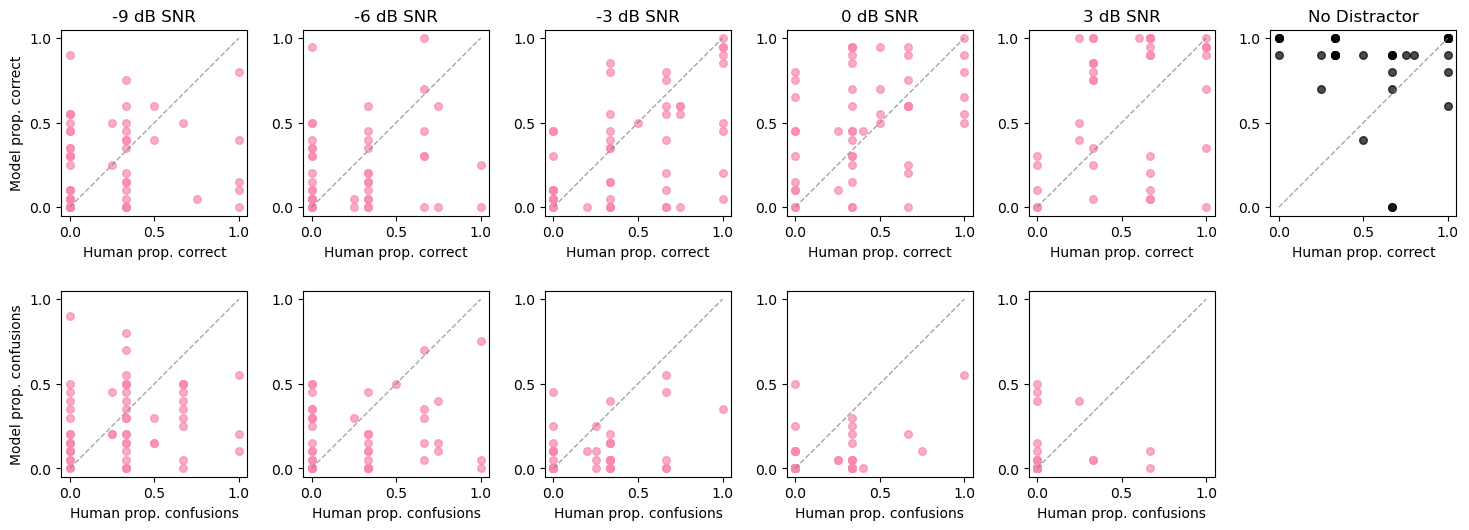

In [21]:
# === Scatter plot comparing human and model performance ===
# -- just use 1-talker condition, plotting each stim_name as a point -- 
# -- each SNR is a different panel -- 
background_conditions = ['1-talker']
snrs = sorted(summary_df.snr.unique())
n_cols = len(snrs)  
n_rows = 2 # plot confusions as bottom row 
aspect = 3 # the size of each panel 

palette = diotic_exp_color_palette()

human_to_compare = summary_df[summary_df.N > 2].copy()

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols*aspect, n_rows*aspect), sharex=False, sharey=False)

def nan_sem(x):
    return np.nanstd(x) / np.sqrt(np.sum(~np.isnan(x)))

def select_df_split(df, cond, snr):
    return df[(df.background_condition == cond) & (df.snr == snr)]

def summarize_data(df):
    # return dict of stim_name, acc mean, acc sem, conf mean, conf sem 
    df = df.groupby('stim_name').agg(
                accuracy_mean=('accuracy', 'mean'),
                accuracy_sem=('accuracy', 'sem'),
                confusion_mean=('confusions', 'mean'),
                confusion_sem=('confusions', 'sem')
            ).reset_index()
    return df


for ax in axes.flatten()[:-1]:
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, alpha=0.7)

for col_i in range(n_cols):
    snr = snrs[col_i]
    for data_cond in background_conditions:
        data_cond = 'clean' if col_i == len(snrs)-1 else data_cond 
        model_data = summarize_data(select_df_split(fba_summary_df, data_cond, snr))
        human_data = summarize_data(select_df_split(human_to_compare, data_cond, snr))

        # only plot data where both human and model have data 
        common_stim_names = set(model_data.stim_name).intersection(set(human_data.stim_name))
        model_data = model_data[model_data.stim_name.isin(common_stim_names)]
        human_data = human_data[human_data.stim_name.isin(common_stim_names)]
        # resort by stim_name to align
        model_data = model_data.sort_values('stim_name')
        human_data = human_data.sort_values('stim_name')

        axes[0, col_i].scatter(human_data.accuracy_mean, model_data.accuracy_mean, s=30, color=palette[data_cond], alpha=0.7)
        # set title 
        axes[0, col_i].set_title(f"{snr} dB SNR" if snr != 6 else "No Distractor")
        if col_i != len(snrs) - 1:
            axes[1, col_i].scatter(human_data.confusion_mean, model_data.confusion_mean, s=30, color=palette[data_cond], alpha=0.7)
        else:
            axes[1, col_i].axis('off')

# label axes 
for row in range(n_rows):
    for col, ax in enumerate(axes[row, :]):
        measure = 'correct' if row == 0 else "confusions" 
        if col == 0:
            ax.set_ylabel(f"Model prop. {measure}")
        ax.set_xlabel(f"Human prop. {measure}")


        ticks = np.linspace(0, 1, 3)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xlim([-0.05, 1.05])
        ax.set_ylim([-0.05, 1.05])
        ax.set_aspect('equal', adjustable='box')


# adjust w space 
fig.subplots_adjust(wspace=0.3, hspace=0.3)


SNR: -9, Condition: 1-talker, Common Stimuli: 536
SNR: -6, Condition: 1-talker, Common Stimuli: 540
SNR: -3, Condition: 1-talker, Common Stimuli: 524
SNR: 0, Condition: 1-talker, Common Stimuli: 542
SNR: 3, Condition: 1-talker, Common Stimuli: 552
SNR: 6, Condition: 1-talker, Common Stimuli: 0
SNR: -9, Condition: 2-talker, Common Stimuli: 538
SNR: -6, Condition: 2-talker, Common Stimuli: 532
SNR: -3, Condition: 2-talker, Common Stimuli: 545
SNR: 0, Condition: 2-talker, Common Stimuli: 543
SNR: 3, Condition: 2-talker, Common Stimuli: 539
SNR: 6, Condition: 2-talker, Common Stimuli: 0
SNR: -9, Condition: 4-talker, Common Stimuli: 532
SNR: -6, Condition: 4-talker, Common Stimuli: 532
SNR: -3, Condition: 4-talker, Common Stimuli: 524
SNR: 0, Condition: 4-talker, Common Stimuli: 534
SNR: 3, Condition: 4-talker, Common Stimuli: 536
SNR: 6, Condition: 4-talker, Common Stimuli: 0
SNR: -9, Condition: babble, Common Stimuli: 535
SNR: -6, Condition: babble, Common Stimuli: 541
SNR: -3, Condition:

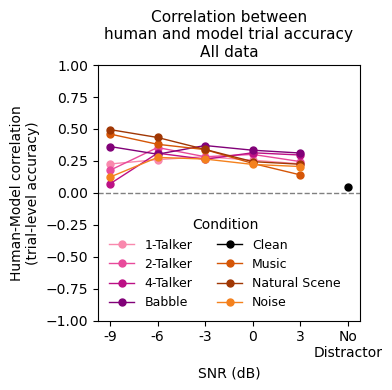

SNR: -9, Condition: 1-talker, Common Stimuli: 12
SNR: -6, Condition: 1-talker, Common Stimuli: 9
SNR: -3, Condition: 1-talker, Common Stimuli: 7
SNR: 0, Condition: 1-talker, Common Stimuli: 9
SNR: 3, Condition: 1-talker, Common Stimuli: 4
SNR: 6, Condition: 1-talker, Common Stimuli: 0
SNR: -9, Condition: 2-talker, Common Stimuli: 7
SNR: -6, Condition: 2-talker, Common Stimuli: 7
SNR: -3, Condition: 2-talker, Common Stimuli: 5
SNR: 0, Condition: 2-talker, Common Stimuli: 5
SNR: 3, Condition: 2-talker, Common Stimuli: 6
SNR: 6, Condition: 2-talker, Common Stimuli: 0
SNR: -9, Condition: 4-talker, Common Stimuli: 5
SNR: -6, Condition: 4-talker, Common Stimuli: 8
SNR: -3, Condition: 4-talker, Common Stimuli: 9
SNR: 0, Condition: 4-talker, Common Stimuli: 10
SNR: 3, Condition: 4-talker, Common Stimuli: 9
SNR: 6, Condition: 4-talker, Common Stimuli: 0
SNR: -9, Condition: babble, Common Stimuli: 6
SNR: -6, Condition: babble, Common Stimuli: 9
SNR: -3, Condition: babble, Common Stimuli: 8
SNR: 

/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


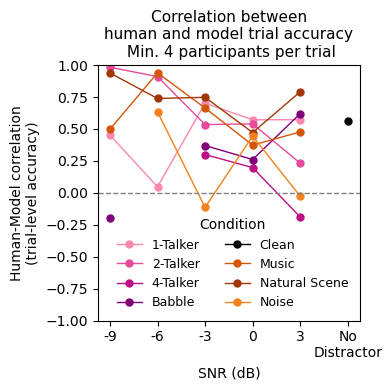

In [67]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# === Setup ===
snrs = sorted(summary_df.snr.unique())
conditions = [cond for cond in sorted(summary_df.background_condition.dropna().unique()) if "Mandar" not in cond]  # or manually define
measure = 'accuracy'  # or 'confusions'

# Filter human data with enough trials
N = 4
human_filtered = summary_df[summary_df.N >= N].copy()

# Store results: {condition: [r-values for each SNR]}
corr_by_condition = {cond: [] for cond in conditions}

# === Compute correlation for each (condition, SNR) ===
for cond in conditions:
    for snr in snrs:
        # Filter and summarize
        human_subset = human_filtered[(human_filtered.background_condition == cond) & (human_filtered.snr == snr)]
        model_subset = fba_summary_df[(fba_summary_df.background_condition == cond) & (fba_summary_df.snr == snr)]

        # Mean per stim
        human_means = human_subset.groupby('stim_name')[measure].mean()
        model_means = model_subset.groupby('stim_name')[measure].mean()

        # Join on common stim_names
        common = human_means.index.intersection(model_means.index)
        print(f"SNR: {snr}, Condition: {cond}, Common Stimuli: {len(common)}")
        if len(common) < 2:
            corr = np.nan  # not enough data
        else:
            r, _ = pearsonr(human_means[common], model_means[common])
            corr = r

        corr_by_condition[cond].append(corr)

# === Plot ===
plt.figure(figsize=(4, 4))

for cond, r_values in corr_by_condition.items():
    cond = 'noise' if cond == 'stationary' else cond  # rename for clarity
    plt.plot(snrs, r_values, marker='o', ms=5, linewidth=1, color=palette[cond], label=cond.title())

fontsize = 10
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel("SNR (dB)", fontsize=fontsize)
plt.xticks(snrs, labels=[str(snr) if snr != 6 else "No\nDistractor" for snr in snrs], fontsize=fontsize)
plt.ylabel(f"Human-Model correlation\n(trial-level {measure})", fontsize=fontsize)
plt.title(f"Correlation between\nhuman and model trial {measure}\n Min. {N} participants per trial", fontsize=fontsize + 1)
plt.legend(title="Condition", frameon=False, ncol=2, fontsize=fontsize-1)
plt.ylim(-1, 1)
# plt.grid(True)
plt.tight_layout()


In [94]:
import h5py
# fname = 'train_gender_balanced_4M_examples_0155031_0160031.hdf5_chunk000'
# fpath = Path('/om/scratch/Fri/imgriff/dataset_binaural_attn/v10/train_gender_balanced/')
# h5 = h5py.File(fpath / fname, 'r')
h5 = h5py.File("/om/user/imgriff/datasets/human_word_rec_SWC_2024/model_eval_stim.h5", 'r')

In [97]:
h5['target_signal'].shape

(976, 110250)

array([1, 2, 1, ..., 3, 2, 2])

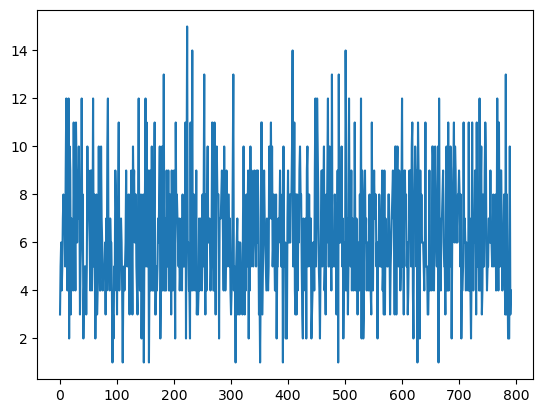

In [91]:
locs = np.stack([h5['label_loc_target_elev'], h5['label_loc_target_azim']], axis=1)
locs, counts = np.unique(locs, axis=0, return_counts=True)
plt.plot(np.arange(len(locs)), counts)

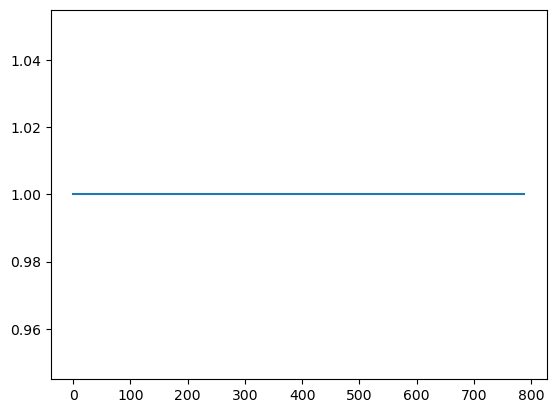